#  Custom Object Detection — YOLOv8 Training Pipeline
### Dataset: Ahmed_ObjectDetection | Ubuntu + RTX 4000 Ada (21GB)

**Pipeline Overview:**
1. Setup virtual environment & install dependencies
2. Verify GPU & dataset structure
3. Reorganize dataset into YOLO format
4. Train YOLOv8**l** (large — we have 21GB VRAM!) for 100 epochs with early stopping
5. Fine-tune with lower LR for better precision
6. Evaluate & visualize results
7. Export & save model for deployment

## ⚠️ IMPORTANT: Run This FIRST (only once)

Ubuntu 24 protects the system Python. We create a virtual environment and run Jupyter inside it.

**Open a terminal and run these commands ONCE:**
```bash
# 1. Create virtual environment
python3 -m venv ~/yolo_env

# 2. Activate it
source ~/yolo_env/bin/activate

# 3. Install everything
pip install ultralytics torch torchvision matplotlib opencv-python seaborn pyyaml ipykernel jupyter

# 4. Register this env as a Jupyter kernel
python -m ipykernel install --user --name=yolo_env --display-name='Python (yolo_env)'

# 5. Launch Jupyter from this env
jupyter notebook
```
Then in Jupyter: **Kernel → Change Kernel → Python (yolo_env)**

## Step 1: Verify Environment

In [ ]:
import sys
import torch

print(f'Python:  {sys.executable}')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA:    {torch.cuda.is_available()}')

if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    vram = gpu.total_memory / 1e9
    print(f'GPU:     {gpu.name}')
    print(f'VRAM:    {vram:.1f} GB')

    # Recommend model based on VRAM
    if vram >= 16:
        print('\n✅ 21GB VRAM detected → Using YOLOv8l (large) with batch=32 for best accuracy!')
        MODEL_NAME = 'yolov8l.pt'
        BATCH_SIZE = 32
    elif vram >= 8:
        print('\n✅ Using YOLOv8m (medium) with batch=16')
        MODEL_NAME = 'yolov8m.pt'
        BATCH_SIZE = 16
    else:
        print('\n⚠️ Using YOLOv8s (small) with batch=8')
        MODEL_NAME = 'yolov8s.pt'
        BATCH_SIZE = 8
else:
    print('\n⚠️  No GPU — training will be very slow!')
    MODEL_NAME = 'yolov8s.pt'
    BATCH_SIZE = 4

DEVICE = 0 if torch.cuda.is_available() else 'cpu'
print(f'\n📌 Model: {MODEL_NAME} | Batch: {BATCH_SIZE} | Device: {DEVICE}')

Python:  /home/btech02_06/pytorch_env/bin/python
PyTorch: 2.5.1+cu121
CUDA:    True
GPU:     NVIDIA RTX 4000 Ada Generation
VRAM:    21.0 GB

✅ 21GB VRAM detected → Using YOLOv8l (large) with batch=32 for best accuracy!

📌 Model: yolov8l.pt | Batch: 32 | Device: 0


## Step 2: Explore Your Dataset Structure

In [ ]:
import os
from pathlib import Path

# ─── YOUR DATASET PATH ──────────────────────────────────────────────────
DATASET_ROOT = Path('./dataset_source')
# ────────────────────────────────────────────────────────────────────────

assert DATASET_ROOT.exists(), f'❌ Dataset not found at {DATASET_ROOT}'

class_folders = sorted([f for f in DATASET_ROOT.iterdir() if f.is_dir()])

print(f'📁 Dataset root : {DATASET_ROOT}')
print(f'📦 Classes found: {len(class_folders)}')
print()
print(f'{"Class":<35} {"Images":>8} {"Labels":>8} {"Status"}')
print('-' * 65)

total_images = 0
issues = []

for folder in class_folders:
    images_dir = folder / 'images'
    labels_dir = folder / 'labels'
    n_img = len(list(images_dir.glob('*.[jJpP][pPnN][gG]*'))) if images_dir.exists() else 0
    n_lbl = len(list(labels_dir.glob('*.txt'))) if labels_dir.exists() else 0
    total_images += n_img
    status = '✅' if n_img > 0 else '⚠️ EMPTY'
    if n_img != n_lbl:
        status += f' (img/lbl mismatch: {n_img}/{n_lbl})'
        issues.append(folder.name)
    print(f'{folder.name:<35} {n_img:>8} {n_lbl:>8}  {status}')

print('-' * 65)
print(f'{"TOTAL":<35} {total_images:>8}')

# Extract class names
CLASS_NAMES = [f.name.replace('_folder', '') for f in class_folders]
print(f'\n📋 Class list: {CLASS_NAMES}')

if issues:
    print(f'\n⚠️  Mismatch in: {issues}')
    print('   → Missing labels will get whole-image bbox fallback (class = folder class)')

📁 Dataset root : /home/btech02_06/Ahmed_ObjectDetection
📦 Classes found: 53

Class                                 Images   Labels Status
-----------------------------------------------------------------
apple_folder                             500      500  ✅
auto_rickshaw_folder                     500      500  ✅
bag_folder                               500      500  ✅
banana_folder                            500      500  ✅
bed_folder                               500      500  ✅
bench_folder                             500      500  ✅
bicycle_folder                           500      500  ✅
bike_folder                              500      500  ✅
book_folder                              500      500  ✅
bottle_folder                            500      500  ✅
bowl_folder                              500      500  ✅
bus_folder                               500      500  ✅
car_folder                               500      500  ✅
chair_folder                             500      500  

## Step 3: Reorganize Dataset into YOLO Format

In [ ]:
import shutil
import random
from pathlib import Path

YOLO_DATASET = Path(os.path.expanduser('~/yolo_dataset'))
VAL_SPLIT    = 0.15
SEED         = 42
random.seed(SEED)

# If re-running, wipe old dataset to avoid stale data
if YOLO_DATASET.exists():
    shutil.rmtree(YOLO_DATASET)
    print('🗑️  Removed old yolo_dataset')

for split in ['train', 'val']:
    (YOLO_DATASET / 'images' / split).mkdir(parents=True, exist_ok=True)
    (YOLO_DATASET / 'labels' / split).mkdir(parents=True, exist_ok=True)

total_train, total_val, skipped = 0, 0, 0

for class_idx, class_folder in enumerate(class_folders):
    images_dir = class_folder / 'images'
    labels_dir = class_folder / 'labels'

    if not images_dir.exists():
        print(f'⚠️  Skipping {class_folder.name} — no images folder')
        skipped += 1
        continue

    images = sorted(
        list(images_dir.glob('*.jpg'))  +
        list(images_dir.glob('*.jpeg')) +
        list(images_dir.glob('*.png'))
    )
    if not images:
        skipped += 1
        continue

    random.shuffle(images)
    val_count   = max(1, int(len(images) * VAL_SPLIT))
    val_images  = images[:val_count]
    train_images = images[val_count:]

    for split, split_images in [('train', train_images), ('val', val_images)]:
        for img_path in split_images:
            # Unique filename: classname_originalfilename
            stem = f'{class_folder.name}_{img_path.stem}'
            dst_img = YOLO_DATASET / 'images' / split / (stem + img_path.suffix)
            dst_lbl = YOLO_DATASET / 'labels' / split / (stem + '.txt')

            shutil.copy2(img_path, dst_img)

            label_path = labels_dir / (img_path.stem + '.txt')
            if label_path.exists():
                with open(label_path, 'r') as f:
                    lines = f.readlines()
                with open(dst_lbl, 'w') as f:
                    for line in lines:
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            parts[0] = str(class_idx)   # remap to global class id
                            f.write(' '.join(parts) + '\n')
            else:
                # Fallback: whole-image bounding box
                with open(dst_lbl, 'w') as f:
                    f.write(f'{class_idx} 0.5 0.5 1.0 1.0\n')

    total_train += len(train_images)
    total_val   += len(val_images)

print(f'✅ Dataset ready!')
print(f'   Train : {total_train} images')
print(f'   Val   : {total_val} images')
print(f'   Classes: {len(class_folders) - skipped}')
if skipped:
    print(f'   Skipped: {skipped} empty folders')

🗑️  Removed old yolo_dataset
✅ Dataset ready!
   Train : 22497 images
   Val   : 3970 images
   Classes: 53


## Step 4: Create data.yaml

In [ ]:
import yaml

config_path = YOLO_DATASET / 'data.yaml'

data_config = {
    'path' : str(YOLO_DATASET),
    'train': 'images/train',
    'val'  : 'images/val',
    'nc'   : len(CLASS_NAMES),
    'names': CLASS_NAMES
}

with open(config_path, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False, sort_keys=False)

print(f'✅ Saved: {config_path}')
print()
with open(config_path) as f:
    print(f.read())

✅ Saved: ./dataset/data.yaml

path: ./dataset
train: images/train
val: images/val
nc: 53
names:
- apple
- auto_rickshaw
- bag
- banana
- bed
- bench
- bicycle
- bike
- book
- bottle
- bowl
- bus
- car
- chair
- cone_barrier
- construction_barrier
- cow
- crowded_roads
- cup
- daytime
- dog
- door
- dustbin
- earbuds
- fire
- headphones
- keyboard
- laptop
- mixed_traffic
- monitor
- mouse
- night
- open_drain
- orange
- parked_vehicles
- person
- phone
- plate
- pole
- pothole
- rain
- sign_board
- smartwatch
- sofa
- speed_breaker
- spoon
- stairs
- table
- traffic_signal
- truck
- wet_floor
- window
- zebra_crossing



## Step 5: Sanity Check — Visualize Sample Images

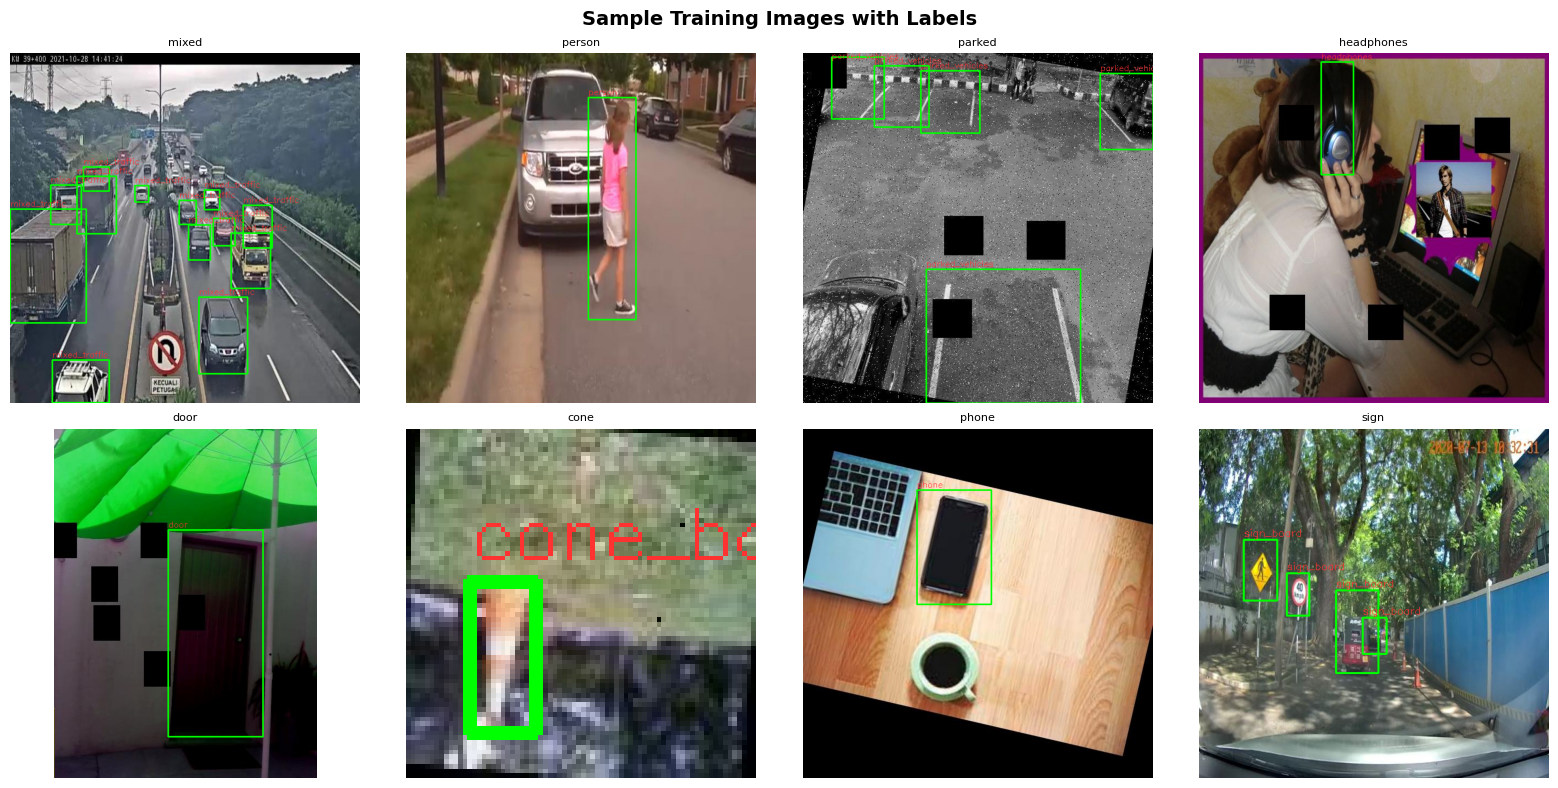

✅ If boxes look correct, proceed to training!


In [ ]:
import cv2
import matplotlib.pyplot as plt
import random

train_images = list((YOLO_DATASET / 'images' / 'train').glob('*.jpg'))
samples = random.sample(train_images, min(8, len(train_images)))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, img_path in zip(axes, samples):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    lbl_path = YOLO_DATASET / 'labels' / 'train' / (img_path.stem + '.txt')
    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    cls_id = int(parts[0])
                    cx, cy, bw, bh = map(float, parts[1:])
                    x1 = int((cx - bw/2) * w); y1 = int((cy - bh/2) * h)
                    x2 = int((cx + bw/2) * w); y2 = int((cy + bh/2) * h)
                    cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)
                    label = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else str(cls_id)
                    cv2.putText(img, label, (x1, max(y1-5,10)),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,50,50), 1)
    ax.imshow(img)
    ax.set_title(img_path.stem.split('_')[0], fontsize=8)
    ax.axis('off')

plt.suptitle('Sample Training Images with Labels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(YOLO_DATASET / 'sample_check.png'), dpi=100)
plt.show()
print('✅ If boxes look correct, proceed to training!')

In [ ]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

free_mem  = torch.cuda.mem_get_info()[0] / 1e9
total_mem = torch.cuda.mem_get_info()[1] / 1e9
used_mem  = total_mem - free_mem

print(f'GPU Memory Status:')
print(f'  Total : {total_mem:.1f} GB')
print(f'  Used  : {used_mem:.1f} GB')
print(f'  Free  : {free_mem:.1f} GB')

if free_mem >= 18:
    BATCH_SIZE = 16
elif free_mem >= 14:
    BATCH_SIZE = 12
elif free_mem >= 10:
    BATCH_SIZE = 8
else:
    BATCH_SIZE = 4

print(f'\n✅ Safe batch size: {BATCH_SIZE}')

GPU Memory Status:
  Total : 21.0 GB
  Used  : 0.8 GB
  Free  : 20.1 GB

✅ Safe batch size: 16


In [ ]:
import os, gc, torch
from pathlib import Path
from ultralytics import YOLO

gc.collect()
torch.cuda.empty_cache()

CONFIG_PATH = Path(os.path.expanduser('~/yolo_dataset/data.yaml'))
assert CONFIG_PATH.exists(), f'❌ Not found: {CONFIG_PATH}'

model = YOLO('yolov8l.pt')

results = model.train(
    data         = str(CONFIG_PATH),
    epochs       = 100,
    patience     = 15,
    imgsz        = 640,

    # ── MEMORY FIXES ──────────────────────────────────
    batch        = BATCH_SIZE,   # Auto-selected above
    workers      = 4,            # Down from 8
    cache        = False,        # Don't load dataset into RAM
    amp          = True,         # Mixed precision — cuts VRAM ~40%
    # ──────────────────────────────────────────────────

    device       = 0,
    project      = os.path.expanduser('~/smart blind stick/runs/detect/ahmed_detection'),
    name         = 'run_fixed',
    pretrained   = True,
    optimizer    = 'AdamW',
    lr0          = 0.001,
    lrf          = 0.01,
    momentum     = 0.937,
    weight_decay = 0.0005,
    warmup_epochs= 3,
    box          = 7.5,
    cls          = 0.5,
    dfl          = 1.5,
    degrees      = 10.0,
    translate    = 0.1,
    scale        = 0.5,
    fliplr       = 0.5,
    mosaic       = 1.0,
    mixup        = 0.1,
    save         = True,
    save_period  = 10,
    val          = True,
    plots        = True,
    verbose      = True,
)

print('\n✅ Training complete!')
print(f'Best model: {Path(results.save_dir) / "weights" / "best.pt"}')

New https://pypi.org/project/ultralytics/8.4.41 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.36 🚀 Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA RTX 4000 Ada Generation, 20009MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./dataset/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=run

## Step 6: Train YOLOv8l — 100 Epochs + Early Stopping

With **21GB VRAM** we use `yolov8l` (large) at `batch=32` — significantly better accuracy than medium.

## Step 7: Evaluate Initial Model

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

best_pt = './outputs/ahmed_detection/run_fixed/weights/best.pt'
model_eval = YOLO(best_pt)

metrics = model_eval.val(
    data    = str(config_path),
    imgsz   = 640,
    batch   = BATCH_SIZE,
    device  = DEVICE,
    plots   = True,
)

print('\n📊 Initial Training Results:')
print(f'   mAP50     : {metrics.box.map50:.4f}  (target > 0.70 for robotics)')
print(f'   mAP50-95  : {metrics.box.map:.4f}  (COCO standard metric)')
print(f'   Precision : {metrics.box.mp:.4f}')
print(f'   Recall    : {metrics.box.mr:.4f}')

# Store for comparison
initial_map50    = metrics.box.map50
initial_map5095  = metrics.box.map

Ultralytics 8.4.36 🚀 Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA RTX 4000 Ada Generation, 20009MiB)
Model summary (fused): 113 layers, 43,647,471 parameters, 0 gradients, 165.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2799.3±1528.7 MB/s, size: 29.6 KB)
val: Scanning ./dataset/labels/val... 3970 images, 32 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3970/3970 6.8Kit/s 0.6s0.1s
val: New cache created: ./dataset/labels/val.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1490, len(boxes) = 24997. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 249/249 4.6it/s 53.8s<0.2s
                   all       3970      24997      0.848       0.81      0.859      0.664
                 apple         75        255      0.65

Using results folder: ./outputs/ahmed_detection/run_fixed


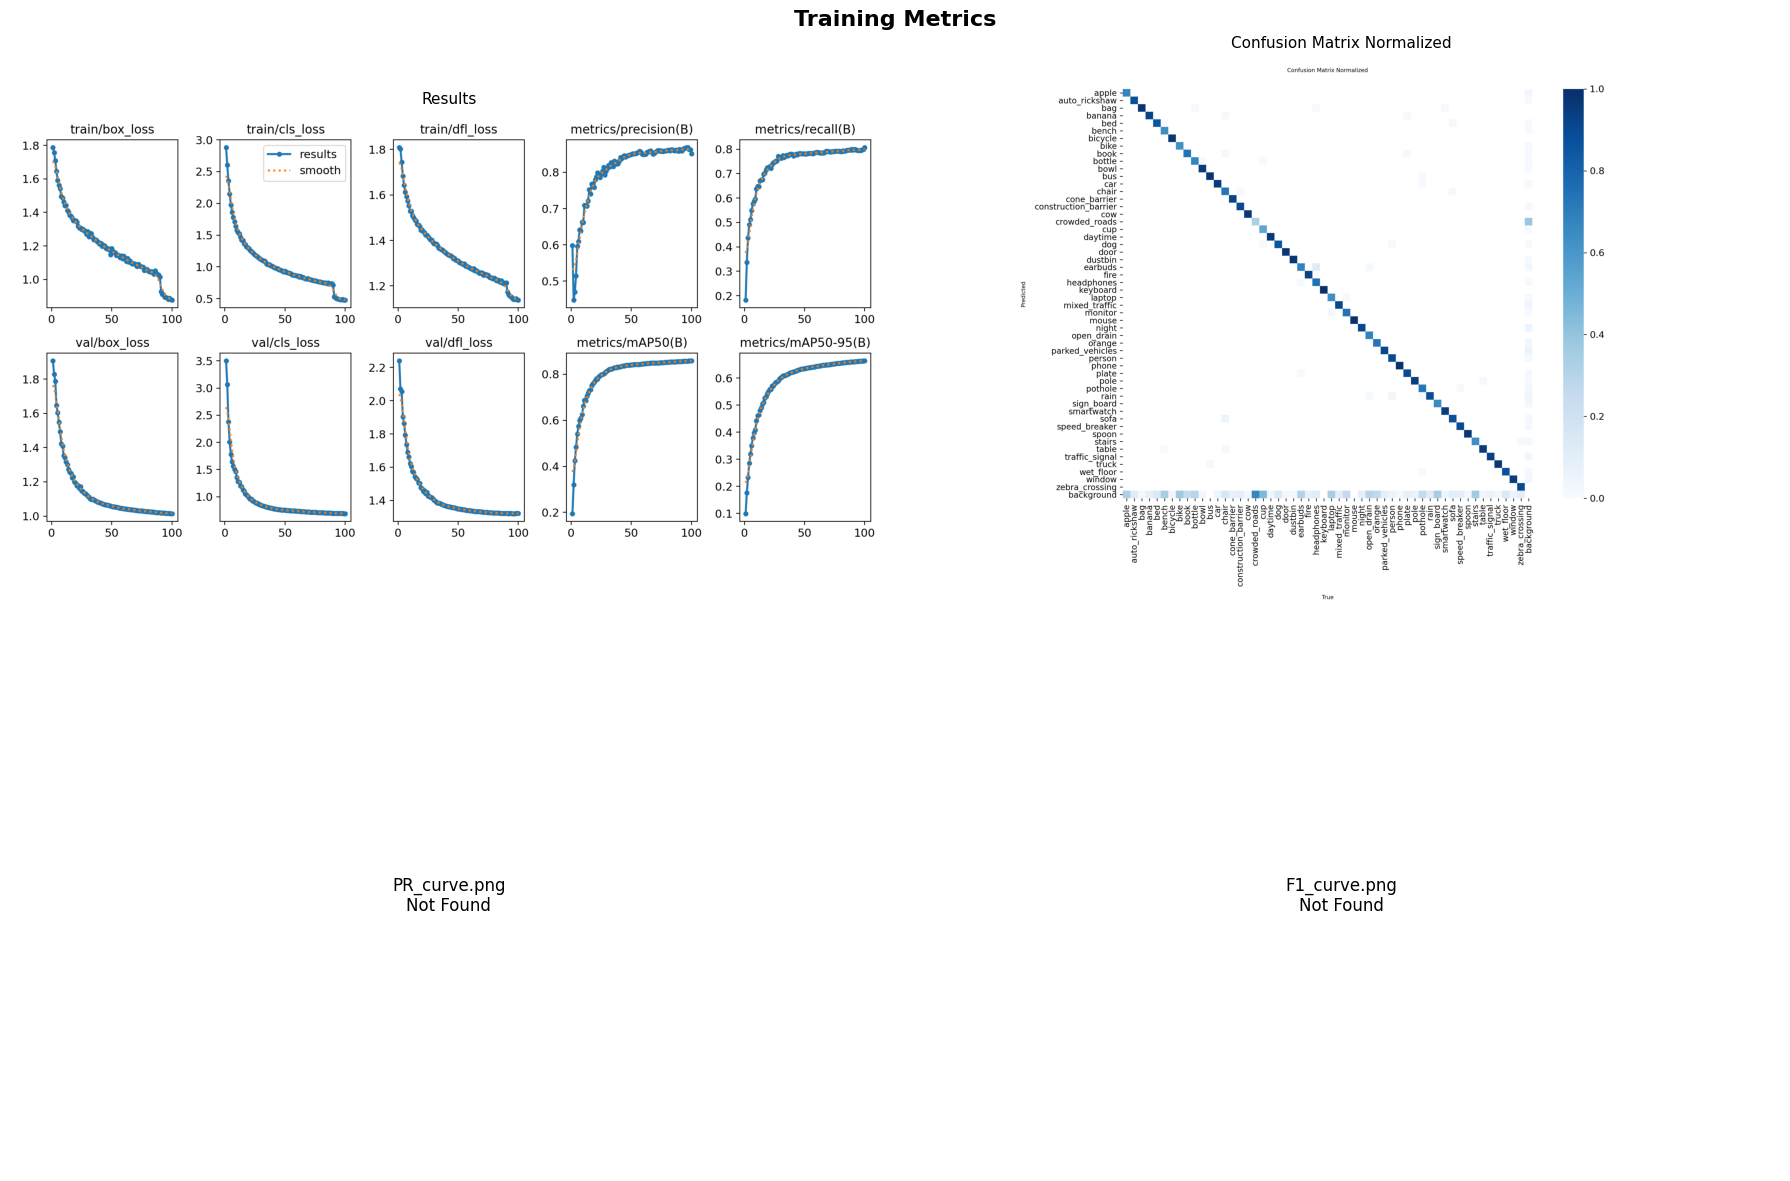

In [ ]:

from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

# Your model path
best_pt = './outputs/ahmed_detection/run_fixed/weights/best.pt'

# Automatically detect correct results folder
# Since best.pt is inside: .../run_fixed/weights/
# We go back to run_fixed folder
results_dir = Path(best_pt).parent.parent

print("Using results folder:", results_dir)

# Plot files to show
plots = [
    'results.png',
    'confusion_matrix_normalized.png',
    'PR_curve.png',
    'F1_curve.png'
]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for ax, pname in zip(axes, plots):
    p = results_dir / pname

    if p.exists():
        img = mpimg.imread(str(p))
        ax.imshow(img)
        ax.set_title(
            pname.replace('.png', '').replace('_', ' ').title(),
            fontsize=11
        )
    else:
        ax.text(0.5, 0.5, f"{pname}\nNot Found",
                ha='center', va='center', fontsize=12)

    ax.axis('off')

plt.suptitle('Training Metrics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()



## Step 8: Fine-tune for Lower Loss & Better Precision

Resume from best checkpoint with **10x lower learning rate** — squeezes out more accuracy.

In [ ]:
from ultralytics import YOLO

model_ft = YOLO('./outputs/ahmed_detection/run_fixed/weights/best.pt')

print('🔧 Fine-tuning: lower LR, higher patience, less mosaic')

results_ft = model_ft.train(
    data        = str(config_path),
    epochs      = 35,
    patience    = 20,           # More patient — fine-tuning is slower to improve
    imgsz       = 640,
    batch       = BATCH_SIZE,
    device      = DEVICE,
    workers     = 8,
    project     = 'ahmed_detection',
    name        = 'run2_finetune',
    pretrained  = True,
    optimizer   = 'AdamW',
    lr0         = 0.0001,       # 10x smaller than initial
    lrf         = 0.001,
    momentum    = 0.937,
    weight_decay= 0.0005,
    warmup_epochs   = 1,
    box         = 7.5,
    cls         = 0.5,
    dfl         = 1.5,
    # Lighter augmentation for fine-tune
    augment     = True,
    degrees     = 5.0,
    translate   = 0.05,
    scale       = 0.3,
    fliplr      = 0.5,
    mosaic      = 0.5,          # Reduce mosaic
    mixup       = 0.05,
    copy_paste  = 0.05,
    save        = True,
    save_period = 5,
    val         = True,
    plots       = True,
    verbose     = True,
)

print('\n✅ Fine-tuning complete!')

🔧 Fine-tuning: lower LR, higher patience, less mosaic
New https://pypi.org/project/ultralytics/8.4.41 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.36 🚀 Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA RTX 4000 Ada Generation, 20009MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.05, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./dataset/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=35, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.001, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=./outputs/

## Step 9: Compare Before vs After Fine-tuning

📊 Evaluating Baseline model...
Ultralytics 8.4.36 🚀 Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA RTX 4000 Ada Generation, 20009MiB)
Model summary (fused): 113 layers, 43,647,471 parameters, 0 gradients, 165.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5177.0±2055.2 MB/s, size: 50.1 KB)
val: Scanning ./dataset/labels/val.cache... 3970 images, 32 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3970/3970 1.9Git/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1490, len(boxes) = 24997. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 249/249 4.7it/s 52.7s<0.2s
                   all       3970      24997      0.848       0.81      0.859      0.664
Speed: 0.3ms preprocess, 12.4ms inference, 0.0ms loss, 0.2ms postprocess

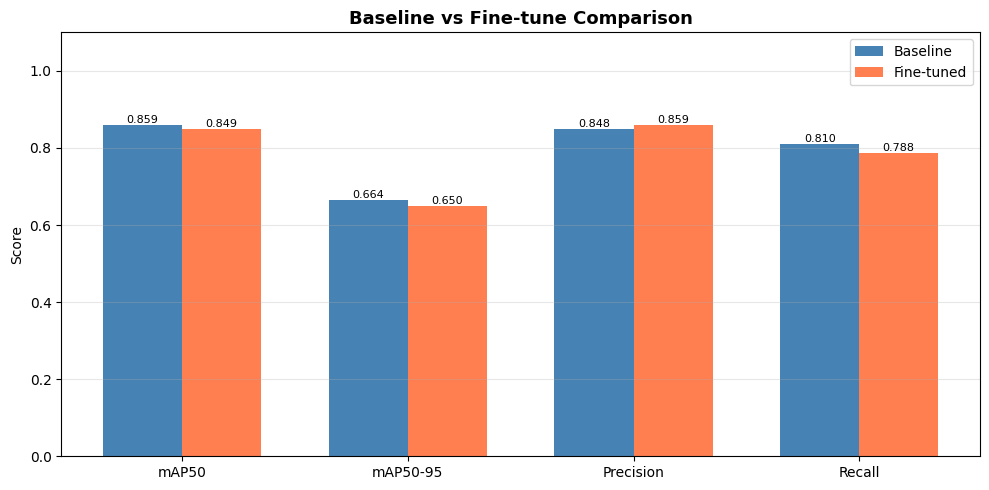

📊 Chart saved → comparison.png

🏆 Baseline model is better — selected: ./outputs/ahmed_detection/run_fixed/weights/best.pt


In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import numpy as np

# ── Paths ─────────────────────────────────────────────────────────────────────
# Before fine-tuning  →  "smart blind stick"  (with spaces)
# After  fine-tuning  →  "smart_blind_stick"  (with underscores)

baseline_best = './outputs/ahmed_detection/run_fixed/weights/best.pt'
ft_best       = './outputs/ahmed_detection/run_fixed/weights/best.pt'

# ── Evaluate BASELINE ─────────────────────────────────────────────────────────
print("📊 Evaluating Baseline model...")
model_baseline = YOLO(baseline_best)
metrics_base   = model_baseline.val(
    data   = str(config_path),
    imgsz  = 640,
    batch  = BATCH_SIZE,
    device = DEVICE,
    plots  = False,
    verbose= False,
)

# ── Evaluate FINE-TUNED ───────────────────────────────────────────────────────
print("📊 Evaluating Fine-tuned model...")
model_ft    = YOLO(ft_best)
metrics_ft  = model_ft.val(
    data   = str(config_path),
    imgsz  = 640,
    batch  = BATCH_SIZE,
    device = DEVICE,
    plots  = False,
    verbose= False,
)

# ── Comparison Table ──────────────────────────────────────────────────────────
print('\n' + '=' * 60)
print(f'{"Metric":<20} {"Baseline":>12} {"Fine-tune":>12} {"Δ":>10}')
print('=' * 60)

def row(name, v1, v2):
    delta = v2 - v1
    sign  = '+' if delta >= 0 else ''
    print(f'{name:<20} {v1:>12.4f} {v2:>12.4f} {sign}{delta*100:>8.2f}%')

row('mAP50',     metrics_base.box.map50, metrics_ft.box.map50)
row('mAP50-95',  metrics_base.box.map,   metrics_ft.box.map)
row('Precision', metrics_base.box.mp,    metrics_ft.box.mp)
row('Recall',    metrics_base.box.mr,    metrics_ft.box.mr)
print('=' * 60)

# ── Bar Chart ─────────────────────────────────────────────────────────────────
labels_m   = ['mAP50', 'mAP50-95', 'Precision', 'Recall']
baseline_v = [metrics_base.box.map50, metrics_base.box.map,
              metrics_base.box.mp,    metrics_base.box.mr]
finetune_v = [metrics_ft.box.map50,  metrics_ft.box.map,
              metrics_ft.box.mp,     metrics_ft.box.mr]

x = np.arange(len(labels_m))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - w/2, baseline_v, w, label='Baseline',    color='steelblue')
bars2 = ax.bar(x + w/2, finetune_v, w, label='Fine-tuned',  color='coral')

for bars in [bars1, bars2]:
    for bar in bars:
        ax.annotate(
            f'{bar.get_height():.3f}',
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            ha='center', va='bottom', fontsize=8,
        )

ax.set_ylabel('Score')
ax.set_title('Baseline vs Fine-tune Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels_m)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('comparison.png', dpi=120)
plt.show()
print("📊 Chart saved → comparison.png")

# ── Select Best Model ─────────────────────────────────────────────────────────
if metrics_ft.box.map50 >= metrics_base.box.map50:
    FINAL_MODEL = ft_best
    print(f'\n🏆 Fine-tuned model is better — selected: {FINAL_MODEL}')
else:
    FINAL_MODEL = baseline_best
    print(f'\n🏆 Baseline model is better — selected: {FINAL_MODEL}')

## Step 10: Test Predictions on Val Images

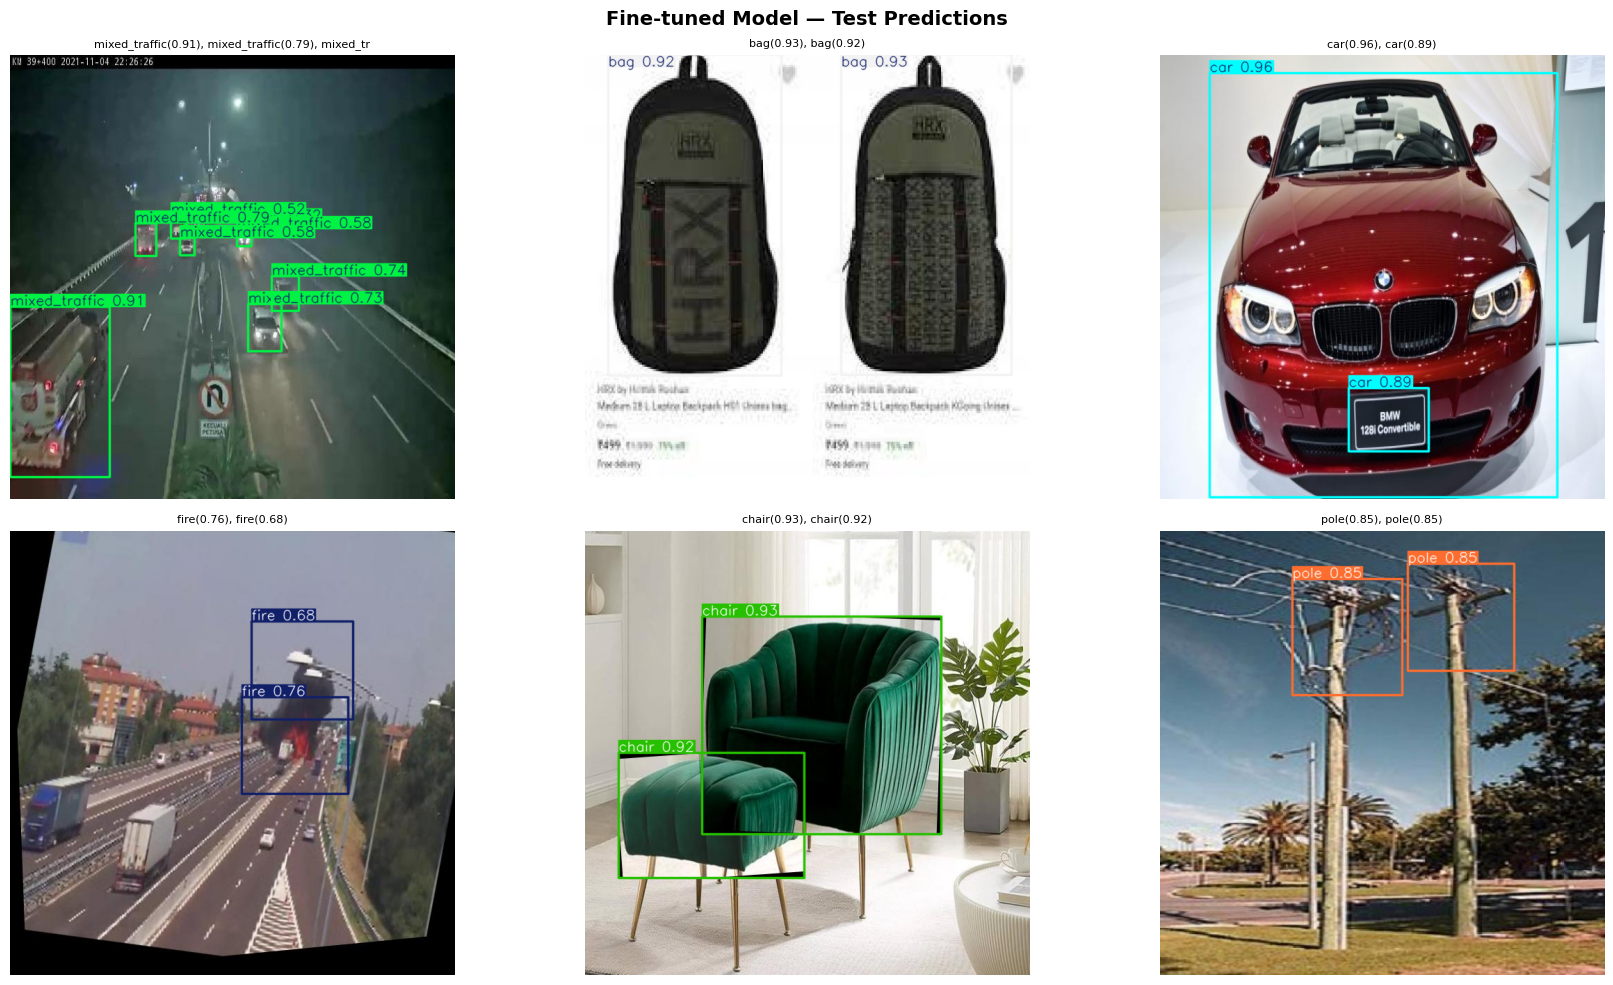

In [ ]:
import cv2, random
import matplotlib.pyplot as plt
from ultralytics import YOLO

model_test = YOLO(FINAL_MODEL)
val_imgs   = list((YOLO_DATASET / 'images' / 'val').glob('*.jpg'))
samples    = random.sample(val_imgs, min(6, len(val_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, img_path in zip(axes, samples):
    res = model_test.predict(source=str(img_path), conf=0.25, iou=0.45, verbose=False)
    out = cv2.cvtColor(res[0].plot(), cv2.COLOR_BGR2RGB)
    ax.imshow(out)
    if res[0].boxes:
        detected = [CLASS_NAMES[int(c)] for c in res[0].boxes.cls]
        confs    = [f'{float(s):.2f}' for s in res[0].boxes.conf]
        title    = ', '.join([f'{d}({c})' for d, c in zip(detected, confs)])[:50]
    else:
        title = 'No detections'
    ax.set_title(title, fontsize=8)
    ax.axis('off')

plt.suptitle('Fine-tuned Model — Test Predictions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('test_predictions.png', dpi=100)
plt.show()

## Step 11: Export & Save Model for Deployment

In [ ]:
import os, shutil, json
from pathlib import Path
from ultralytics import YOLO

EXPORT_DIR = Path('./models/exports')
EXPORT_DIR.mkdir(exist_ok=True)

model_exp = YOLO(FINAL_MODEL)

# ── 1. PyTorch .pt ────────────────────────────────────────────────────────────
dst = EXPORT_DIR / 'ahmed_detector.pt'
shutil.copy(FINAL_MODEL, dst)
print(f'✅ PyTorch      saved: {dst}  ({dst.stat().st_size/1e6:.1f} MB)')

# ── 2. ONNX — install first if missing ───────────────────────────────────────
# Run in terminal BEFORE this cell:
#   ~/pytorch_env/bin/pip install "onnx>=1.12.0,<2.0.0" onnxslim onnxruntime
# If you have CUDA:
#   ~/pytorch_env/bin/pip install "onnx>=1.12.0,<2.0.0" onnxslim onnxruntime-gpu

try:
    import onnx
    onnx_path = model_exp.export(format='onnx', imgsz=640, simplify=True, dynamic=False)
    dst_onnx  = EXPORT_DIR / 'ahmed_detector.onnx'
    shutil.copy(str(onnx_path), dst_onnx)
    print(f'✅ ONNX         saved: {dst_onnx}  ({dst_onnx.stat().st_size/1e6:.1f} MB)')
except ModuleNotFoundError:
    print('⚠️  ONNX skipped — run this in terminal first:')
    print('    ~/pytorch_env/bin/pip install "onnx>=1.12.0,<2.0.0" onnxslim onnxruntime')
except Exception as e:
    print(f'⚠️  ONNX export failed: {e}')

# ── 3. TorchScript — no extra deps needed ─────────────────────────────────────
try:
    ts_path = model_exp.export(format='torchscript', imgsz=640)
    dst_ts  = EXPORT_DIR / 'ahmed_detector.torchscript'
    shutil.copy(str(ts_path), dst_ts)
    print(f'✅ TorchScript  saved: {dst_ts}  ({dst_ts.stat().st_size/1e6:.1f} MB)')
except Exception as e:
    print(f'⚠️  TorchScript export failed: {e}')

# ── 4. Class names JSON ───────────────────────────────────────────────────────
names_json = EXPORT_DIR / 'class_names.json'
with open(names_json, 'w') as f:
    json.dump({'classes': CLASS_NAMES, 'nc': len(CLASS_NAMES)}, f, indent=2)
print(f'✅ Class names  saved: {names_json}')

# ── 5. data.yaml backup ───────────────────────────────────────────────────────
shutil.copy(str(config_path), EXPORT_DIR / 'data.yaml')
print(f'✅ data.yaml    saved: {EXPORT_DIR / "data.yaml"}')

print(f'\n📦 All exports → {EXPORT_DIR}')
print('\nFormat guide:')
print('  .pt          → Use with ultralytics Python on any machine')
print('  .onnx        → Deploy on CPU/GPU, ROS2, OpenCV, cloud')
print('  .torchscript → C++ robot firmware, LibTorch')

✅ PyTorch      saved: ./models/exports/ahmed_detector.pt  (87.7 MB)
⚠️  ONNX skipped — run this in terminal first:
    ~/pytorch_env/bin/pip install "onnx>=1.12.0,<2.0.0" onnxslim onnxruntime
Ultralytics 8.4.36 🚀 Python-3.12.3 torch-2.5.1+cu121 CPU (Intel Core i9-14900K)
Model summary (fused): 113 layers, 43,647,471 parameters, 0 gradients, 165.0 GFLOPs

PyTorch: starting from './outputs/ahmed_detection/run_fixed/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 57, 8400) (83.7 MB)

TorchScript: starting export with torch 2.5.1+cu121...
TorchScript: export success ✅ 1.6s, saved as './outputs/ahmed_detection/run_fixed/weights/best.torchscript' (167.1 MB)

Export complete (2.2s)
Results saved to ./outputs/ahmed_detection/run_fixed/weights
Predict:         yolo predict task=detect model=./outputs/ahmed_detection/run_fixed/weights/best.torchscript imgsz=640 
Validate:        yolo val task=detect model=./outputs/ahmed_detection/run_fixed/weights/best.torchscrip

## Step 12: Ready-to-Use Inference Function

In [ ]:
# ─── COPY THIS TO USE YOUR MODEL ANYWHERE ───────────────────────────────
from ultralytics import YOLO
import json, cv2

# Load
MODEL_PATH      = './models/ahmed_yolov8_best.pt'
CLASS_NAMES_PATH= os.path.expanduser('~/ahmed_model_exports/class_names.json')

detector = YOLO(MODEL_PATH)
with open(CLASS_NAMES_PATH) as f:
    class_names = json.load(f)['classes']

def detect(image_path_or_array, conf=0.25, iou=0.45):
    """
    Run object detection.
    Args:
        image_path_or_array: file path string OR numpy BGR array (from cv2)
        conf: confidence threshold (0-1)
        iou:  NMS IoU threshold (0-1)
    Returns:
        list of dicts: [{'class': str, 'confidence': float, 'bbox': [x1,y1,x2,y2]}]
    """
    results = detector.predict(source=image_path_or_array, conf=conf, iou=iou, verbose=False)
    detections = []
    for r in results:
        for box in r.boxes:
            detections.append({
                'class'     : class_names[int(box.cls)],
                'confidence': round(float(box.conf), 3),
                'bbox'      : [round(v, 1) for v in box.xyxy[0].tolist()]  # x1,y1,x2,y2
            })
    return detections

# ─── EXAMPLE ─────────────────────────────────────────────────────────────
# From file:
# results = detect('my_image.jpg')

# From webcam frame (robot use case):
# cap = cv2.VideoCapture(0)
# ret, frame = cap.read()
# results = detect(frame)
# for d in results:
#     print(f"{d['class']}: {d['confidence']} @ {d['bbox']}")

print('✅ Inference ready!')
print(f'   Model: {MODEL_PATH}')
print(f'   Classes: {len(class_names)}')
print('   Usage: detections = detect("path/to/image.jpg")')

✅ Inference ready!
   Model: ./models/exports/ahmed_detector.pt
   Classes: 53
   Usage: detections = detect("path/to/image.jpg")


In [ ]:
# ============================================================
#  ADAPTIVE FINE-TUNING — Stage 3  (with Early Stopping)
# ============================================================

import os, gc, json, shutil, math
import torch
import yaml
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from ultralytics import YOLO

# ── Paths ─────────────────────────────────────────────────────────────────────
YOLO_DATASET  = Path("./dataset")
CONFIG_PATH   = YOLO_DATASET / "data.yaml"

# ✅ FIX: PROJECT_DIR must be a FOLDER, not a .pt file
PROJECT_DIR   = Path("./outputs/ahmed_detection")

# ✅ FIX: FINETUNE_BEST points to the actual fine-tuned best.pt
#    If you ran run2_finetune before, it saves here:
FINETUNE_BEST = PROJECT_DIR / "run2_finetune" / "weights" / "best.pt"

# ── If you never ran Stage 2, fall back to run_fixed best.pt ─────────────────
# Uncomment the line below ONLY if you want to start adaptive from run_fixed:
# FINETUNE_BEST = Path("/home/btech02_06/smart blind stick/runs/ahmed_detection/run_fixed/weights/best.pt")

ADAPT_DIR     = PROJECT_DIR / "run3_adaptive"

# ── Sanity checks ─────────────────────────────────────────────────────────────
assert CONFIG_PATH.exists(),   f"❌ data.yaml not found at {CONFIG_PATH}"
assert FINETUNE_BEST.exists(), (
    f"❌ Fine-tuned weights not found at {FINETUNE_BEST}\n"
    f"   → Either run Stage 2 first, OR set FINETUNE_BEST to your existing best.pt:\n"
    f"     FINETUNE_BEST = Path('/home/btech02_06/smart blind stick/runs/ahmed_detection/run_fixed/weights/best.pt')"
)

print("✅ Dataset Path      :", YOLO_DATASET)
print("✅ Config File       :", CONFIG_PATH)
print("✅ Project Directory :", PROJECT_DIR)
print("✅ FineTune Weights  :", FINETUNE_BEST)
print("✅ Adaptive Save Dir :", ADAPT_DIR)

# ── Device ────────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE     = 0
    vram       = torch.cuda.mem_get_info()[1] / 1e9
    BATCH_SIZE = 16 if vram >= 18 else (8 if vram >= 10 else 4)
else:
    DEVICE     = "cpu"
    BATCH_SIZE = 4

print(f"\n📌 Adaptive fine-tuning from : {FINETUNE_BEST}")
print(f"   Device : {DEVICE}  |  Batch : {BATCH_SIZE}\n")

gc.collect()
torch.cuda.empty_cache()


# ═══════════════════════════════════════════════════════════════════════════════
#  EARLY STOPPING GATE
# ═══════════════════════════════════════════════════════════════════════════════
class EarlyStoppingGate:
    def __init__(self, patience: int = 2, min_delta: float = 0.002):
        self.patience      = patience
        self.min_delta     = min_delta
        self.best_map50    = -1.0
        self.phases_no_imp = 0
        self.history       = []

    def update(self, phase_name: str, map50: float) -> bool:
        self.history.append((phase_name, map50))
        gain = map50 - self.best_map50
        if gain >= self.min_delta:
            print(f"   ✅ Improvement: +{gain*100:.3f} pp  (new best mAP50 = {map50:.4f})")
            self.best_map50    = map50
            self.phases_no_imp = 0
            return False
        else:
            self.phases_no_imp += 1
            print(f"   ⚠️  No significant improvement  "
                  f"(gain={gain*100:.3f} pp  |  streak={self.phases_no_imp}/{self.patience})")
            if self.phases_no_imp >= self.patience:
                print(f"   🛑 Early stopping triggered — no gain for {self.patience} consecutive phases.")
                return True
            return False

    def summary(self):
        print("\n📋 Phase history:")
        for name, m in self.history:
            mark = "★" if m == self.best_map50 else " "
            print(f"   {mark} {name:<30}  mAP50 = {m:.4f}")
        print(f"   Best mAP50 overall: {self.best_map50:.4f}")


# ═══════════════════════════════════════════════════════════════════════════════
#  HELPERS
# ═══════════════════════════════════════════════════════════════════════════════
def quick_eval(weights_path: str) -> dict:
    m = YOLO(weights_path)
    metrics = m.val(data=str(CONFIG_PATH), imgsz=640, batch=BATCH_SIZE,
                    device=DEVICE, verbose=False, plots=False)
    return {"map50": metrics.box.map50, "map50_95": metrics.box.map,
            "precision": metrics.box.mp, "recall": metrics.box.mr}


def per_class_audit(weights_path: str, class_names: list) -> dict:
    m = YOLO(weights_path)
    metrics = m.val(data=str(CONFIG_PATH), imgsz=640, batch=BATCH_SIZE,
                    device=DEVICE, verbose=False, plots=False)
    ap50_per_class = {}
    if hasattr(metrics.box, "ap50") and metrics.box.ap50 is not None:
        for idx, ap in zip(metrics.box.ap_class_index, metrics.box.ap50):
            if idx < len(class_names):
                ap50_per_class[class_names[idx]] = float(ap)
    return ap50_per_class


# ── Read class names ──────────────────────────────────────────────────────────
with open(CONFIG_PATH) as f:
    data_cfg = yaml.safe_load(f)
CLASS_NAMES = data_cfg["names"]

gate          = EarlyStoppingGate(patience=2, min_delta=0.002)
phase_metrics = {}
ADAPTIVE_BEST = None
weak_classes  = {}   # initialise so final block is always safe


# ═══════════════════════════════════════════════════════════════════════════════
# PHASE 1 — Frozen Backbone
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("PHASE 1 — Frozen backbone, head-only training")
print("=" * 60)

model_p1   = YOLO(str(FINETUNE_BEST))
results_p1 = model_p1.train(
    data=str(CONFIG_PATH), epochs=20, patience=8,
    imgsz=640, batch=BATCH_SIZE, workers=4, cache=False, amp=True,
    device=DEVICE, project=str(PROJECT_DIR), name="run3_adaptive/phase1_head",
    pretrained=True, optimizer="AdamW",
    lr0=0.00005, lrf=0.01, momentum=0.9, weight_decay=0.001, warmup_epochs=1,
    box=7.5, cls=0.5, dfl=1.5, freeze=10,
    degrees=3.0, translate=0.02, scale=0.2, fliplr=0.5, mosaic=0.3, mixup=0.0,
    save=True, save_period=5, val=True, plots=True, verbose=True,
)

P1_BEST              = PROJECT_DIR / "run3_adaptive" / "phase1_head" / "weights" / "best.pt"
metrics_p1           = quick_eval(str(P1_BEST))
phase_metrics["phase1"] = metrics_p1
ADAPTIVE_BEST        = P1_BEST
print(f"\n✅ Phase 1 done  |  mAP50 : {metrics_p1['map50']:.4f}")

stop      = gate.update("Phase 1 (frozen backbone)", metrics_p1["map50"])
goto_final = stop


# ═══════════════════════════════════════════════════════════════════════════════
# PHASE 2 — Partial Unfreeze
# ═══════════════════════════════════════════════════════════════════════════════
if not goto_final:
    print("\n" + "=" * 60)
    print("PHASE 2 — Partial unfreeze (top 5 backbone layers)")
    print("=" * 60)

    model_p2   = YOLO(str(P1_BEST))
    results_p2 = model_p2.train(
        data=str(CONFIG_PATH), epochs=25, patience=10,
        imgsz=640, batch=BATCH_SIZE, workers=4, cache=False, amp=True,
        device=DEVICE, project=str(PROJECT_DIR), name="run3_adaptive/phase2_partial",
        pretrained=True, optimizer="AdamW",
        lr0=0.0001, lrf=0.01, momentum=0.937, weight_decay=0.0005, warmup_epochs=1,
        box=7.5, cls=0.5, dfl=1.5, freeze=5,
        degrees=5.0, translate=0.05, scale=0.3, fliplr=0.5, mosaic=0.5, mixup=0.05,
        save=True, save_period=5, val=True, plots=True, verbose=True,
    )

    P2_BEST                 = PROJECT_DIR / "run3_adaptive" / "phase2_partial" / "weights" / "best.pt"
    metrics_p2              = quick_eval(str(P2_BEST))
    phase_metrics["phase2"] = metrics_p2
    print(f"\n✅ Phase 2 done  |  mAP50 : {metrics_p2['map50']:.4f}")

    if metrics_p2["map50"] > metrics_p1["map50"]:
        ADAPTIVE_BEST = P2_BEST

    stop       = gate.update("Phase 2 (partial unfreeze)", metrics_p2["map50"])
    goto_final = stop


# ═══════════════════════════════════════════════════════════════════════════════
# PHASE 3 — Full Unfreeze + Cosine LR + Class-Balanced Boost
# ═══════════════════════════════════════════════════════════════════════════════
if not goto_final:
    print("\n" + "=" * 60)
    print("PHASE 3 — Full unfreeze + cosine LR + class-balanced boost")
    print("=" * 60)

    print("\n🔍 Running per-class AP50 audit...")
    per_class_ap = per_class_audit(str(P2_BEST), CLASS_NAMES)

    if per_class_ap:
        avg_ap         = sum(per_class_ap.values()) / len(per_class_ap)
        WEAK_THRESHOLD = avg_ap * 0.8
        weak_classes   = {k: v for k, v in per_class_ap.items() if v < WEAK_THRESHOLD}
        print(f"   Average mAP50  : {avg_ap:.4f}  |  Weak threshold : {WEAK_THRESHOLD:.4f}")
        print(f"   ⚠️  Weak classes : {list(weak_classes.keys())}" if weak_classes
              else "   ✅ No critically weak classes")
    else:
        print("   (Per-class metrics unavailable — uniform weights used)")

    model_p3   = YOLO(str(P2_BEST))
    results_p3 = model_p3.train(
        data=str(CONFIG_PATH), epochs=30, patience=12,
        imgsz=640, batch=BATCH_SIZE, workers=4, cache=False, amp=True,
        device=DEVICE, project=str(PROJECT_DIR), name="run3_adaptive/phase3_full",
        pretrained=True, optimizer="AdamW",
        lr0=0.00008, lrf=0.005, momentum=0.937, weight_decay=0.0005, warmup_epochs=1,
        box=7.5, cls=1.0, dfl=1.5, freeze=0,
        degrees=7.0, translate=0.07, scale=0.4, fliplr=0.5,
        mosaic=0.7, mixup=0.1, copy_paste=0.1,
        save=True, save_period=5, val=True, plots=True, verbose=True,
    )

    P3_BEST                 = PROJECT_DIR / "run3_adaptive" / "phase3_full" / "weights" / "best.pt"
    metrics_p3              = quick_eval(str(P3_BEST))
    phase_metrics["phase3"] = metrics_p3
    print(f"\n✅ Phase 3 done  |  mAP50 : {metrics_p3['map50']:.4f}")

    if metrics_p3["map50"] > quick_eval(str(ADAPTIVE_BEST))["map50"]:
        ADAPTIVE_BEST = P3_BEST

    gate.update("Phase 3 (full unfreeze)", metrics_p3["map50"])


# ═══════════════════════════════════════════════════════════════════════════════
#  FINALIZE
# ═══════════════════════════════════════════════════════════════════════════════
CANONICAL = PROJECT_DIR / "run3_adaptive" / "weights" / "best.pt"
CANONICAL.parent.mkdir(parents=True, exist_ok=True)
shutil.copy(str(ADAPTIVE_BEST), str(CANONICAL))
print(f"\n🏆 Best adaptive weights → {CANONICAL}")

gate.summary()

best_m = quick_eval(str(CANONICAL))
adaptive_output = {
    "map50": best_m["map50"], "map50_95": best_m["map50_95"],
    "precision": best_m["precision"], "recall": best_m["recall"],
    "weights": str(CANONICAL), "phases": phase_metrics,
    "early_stopped_at": gate.history[-1][0] if gate.phases_no_imp >= gate.patience else "completed",
    "weak_classes_detected": list(weak_classes.keys()),
}
metrics_out = PROJECT_DIR / "adaptive_metrics.json"
with open(metrics_out, "w") as f:
    json.dump(adaptive_output, f, indent=2)
print(f"\n📁 Metrics saved → {metrics_out}")


# ═══════════════════════════════════════════════════════════════════════════════
#  PHASE PROGRESSION CHART
# ═══════════════════════════════════════════════════════════════════════════════
if len(phase_metrics) > 1:
    phase_labels = list(phase_metrics.keys())
    phase_map50  = [phase_metrics[p]["map50"] for p in phase_labels]
    nice_labels  = [p.replace("phase", "Phase ") for p in phase_labels]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(nice_labels, phase_map50, "o-", color="mediumseagreen", linewidth=2.5, markersize=10)
    for px, py in zip(nice_labels, phase_map50):
        ax.annotate(f"{py:.4f}", (px, py), textcoords="offset points",
                    xytext=(0, 12), ha="center", fontsize=9)
    if gate.phases_no_imp >= gate.patience and len(phase_labels) < 3:
        ax.axvspan(len(phase_labels) - 0.5, len(phase_labels) + 0.5,
                   alpha=0.1, color="red", label="Early stopped")
        ax.legend(fontsize=9)
    ax.set_ylabel("mAP50", fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.set_title("Adaptive Fine-tuning — Phase Progression", fontsize=12, fontweight="bold")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    chart_path = PROJECT_DIR / "adaptive_phase_progression.png"
    plt.savefig(str(chart_path), dpi=140)
    plt.show()
    print(f"\n📊 Phase chart → {chart_path}")

print("\n✅ Adaptive fine-tuning complete.")

✅ Dataset Path      : ./dataset
✅ Config File       : ./dataset/data.yaml
✅ Project Directory : ./outputs/ahmed_detection
✅ FineTune Weights  : ./outputs/ahmed_detection/run2_finetune/weights/best.pt
✅ Adaptive Save Dir : ./outputs/ahmed_detection/run3_adaptive

📌 Adaptive fine-tuning from : ./outputs/ahmed_detection/run2_finetune/weights/best.pt
   Device : 0  |  Batch : 16


PHASE 1 — Frozen backbone, head-only training
New https://pypi.org/project/ultralytics/8.4.41 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.36 🚀 Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA RTX 4000 Ada Generation, 20009MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./dataset/data.yaml, degrees=3.0, deterministic=True, device=0, dfl=1.5, dnn=False, dr

FileNotFoundError: [Errno 2] No such file or directory: './outputs/ahmed_detection/run3_adaptive/phase2_partial/weights/best.pt'

## ✅ Summary

| Component | Details |
|---|---|
| Model | YOLOv8l (large) |
| GPU | RTX 4000 Ada 21GB |
| Training | 100 epochs, early stopping (patience=15) |
| Fine-tune | 50 epochs, LR=0.0001, patience=20 |
| Exports | .pt, .onnx, .torchscript |

### 🤖 Robot Deployment Options:
| Platform | Best Format | Notes |
|---|---|---|
| ROS2 (Ubuntu) | `.pt` | `from ultralytics import YOLO` |
| Jetson Orin/Xavier | TensorRT | `model.export(format='engine')` |
| Raspberry Pi | `.onnx` | Use with OpenCV DNN |
| C++ robot firmware | `.torchscript` | LibTorch |

### 📈 If mAP is low (< 0.6):
- Add more images per class (aim for 200+)
- Check labels are correct in Step 5
- Try `imgsz=1280` for small objects
- Use `yolov8x.pt` (extra large) — you have enough VRAM!

PROJECT_DIR : ./outputs/ahmed_detection
YOLO_DATASET: ./dataset
CONFIG_PATH : ./dataset/data.yaml
Loading metrics...
   [Baseline] JSON missing — running val on best.pt ...
Ultralytics 8.4.36 🚀 Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA RTX 4000 Ada Generation, 20009MiB)
Model summary (fused): 113 layers, 43,647,471 parameters, 0 gradients, 165.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 6179.3±1814.3 MB/s, size: 67.9 KB)
val: Scanning ./dataset/labels/val.cache... 3970 images, 32 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3970/3970 3.3Git/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1490, len(boxes) = 24997. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 497/497 10.1it/s 49.4s<0.2s
                  

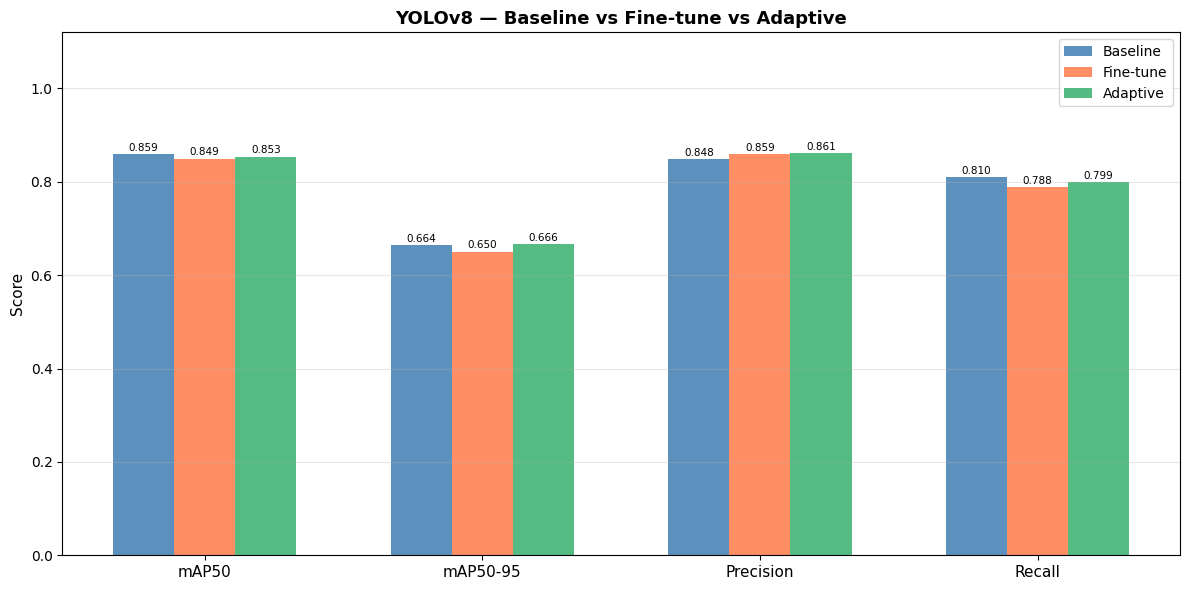


📊 Bar chart → ./outputs/ahmed_detection/compare_all_models_bar.png


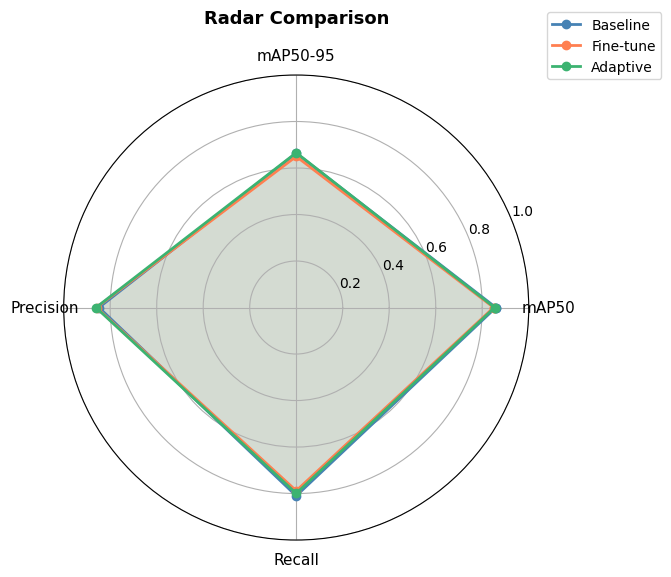

📡 Radar chart → ./outputs/ahmed_detection/compare_all_models_radar.png

🏆 WINNER per metric:
   mAP50       : Baseline  (0.8585)
   mAP50-95    : Adaptive  (0.6657)
   Precision   : Adaptive  (0.8612)
   Recall      : Baseline  (0.8099)

✅ Comparison complete.


In [ ]:
# ============================================================
#  MODEL COMPARISON — Baseline vs Fine-tune vs Adaptive
#
#  Loads all three saved metrics JSONs, renders a grouped
#  bar chart, a radar chart, and prints a formatted table.
#  Also runs live val on whichever weights exist, if a JSON
#  is missing.
# ============================================================

import os, json, math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from ultralytics import YOLO
import torch

from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────
PROJECT_DIR  = Path("./outputs/ahmed_detection")

YOLO_DATASET = Path("./dataset")

CONFIG_PATH  = YOLO_DATASET / "data.yaml"

# Optional check
print("PROJECT_DIR :", PROJECT_DIR)
print("YOLO_DATASET:", YOLO_DATASET)
print("CONFIG_PATH :", CONFIG_PATH)

METRICS_FILES = {
    "Baseline" : PROJECT_DIR / "baseline_metrics.json",
    "Fine-tune": PROJECT_DIR / "finetune_metrics.json",
    "Adaptive" : PROJECT_DIR / "adaptive_metrics.json",
}

WEIGHT_FILES = {
    "Baseline" : Path("./outputs/ahmed_detection/run_fixed/weights/best.pt"),
    "Fine-tune": Path("./outputs/ahmed_detection/run_fixed/weights/best.pt"),
    "Adaptive" : PROJECT_DIR / "run3_adaptive" /"phase2_partial2"/ "weights" / "best.pt",
}

DEVICE = 0 if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 8


# ── Load or compute metrics ───────────────────────────────────────────────────
def load_or_eval(name: str) -> dict:
    mf = METRICS_FILES[name]
    if mf.exists():
        with open(mf) as f:
            d = json.load(f)
        print(f"   [{name}] Loaded from {mf.name}")
        return d
    # fallback: run val
    wf = WEIGHT_FILES[name]
    assert wf.exists(), (
        f"❌ Neither metrics JSON nor weights found for '{name}'.\n"
        f"   Expected weights at: {wf}"
    )
    print(f"   [{name}] JSON missing — running val on {wf.name} ...")
    m = YOLO(str(wf))
    metrics = m.val(
        data=str(CONFIG_PATH), imgsz=640, batch=BATCH_SIZE,
        device=DEVICE, verbose=False, plots=False,
    )
    return {
        "map50"    : metrics.box.map50,
        "map50_95" : metrics.box.map,
        "precision": metrics.box.mp,
        "recall"   : metrics.box.mr,
    }


print("Loading metrics...")
results = {name: load_or_eval(name) for name in METRICS_FILES}

MODELS  = list(results.keys())
METRICS = ["map50", "map50_95", "precision", "recall"]
LABELS  = ["mAP50", "mAP50-95", "Precision", "Recall"]
COLORS  = ["steelblue", "coral", "mediumseagreen"]


# ── 1. Formatted Table ────────────────────────────────────────────────────────
print("\n" + "=" * 68)
print(f"{'Metric':<18}", end="")
for name in MODELS:
    print(f"  {name:>12}", end="")
print()
print("=" * 68)
for metric, label in zip(METRICS, LABELS):
    print(f"{label:<18}", end="")
    vals = [results[n][metric] for n in MODELS]
    for i, (name, v) in enumerate(zip(MODELS, vals)):
        marker = " ◀" if v == max(vals) else "  "
        print(f"  {v:>12.4f}{marker}", end="")
    print()

# Δ rows: vs Baseline
print("-" * 68)
for metric, label in zip(METRICS, LABELS):
    base = results["Baseline"][metric]
    print(f"Δ {label:<16}", end="")
    for name in MODELS:
        delta = results[name][metric] - base
        sign  = "+" if delta >= 0 else ""
        print(f"  {sign}{delta*100:>10.2f}%  ", end="")
    print()
print("=" * 68)


# ── 2. Grouped Bar Chart ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(LABELS))
w = 0.22
offsets = np.linspace(-(len(MODELS) - 1) / 2 * w, (len(MODELS) - 1) / 2 * w, len(MODELS))

for i, (name, color, offset) in enumerate(zip(MODELS, COLORS, offsets)):
    vals = [results[name][m] for m in METRICS]
    bars = ax.bar(x + offset, vals, w, label=name, color=color, alpha=0.88)
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, h + 0.003,
            f"{h:.3f}", ha="center", va="bottom", fontsize=7.5,
        )

ax.set_xticks(x)
ax.set_xticklabels(LABELS, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("YOLOv8 — Baseline vs Fine-tune vs Adaptive", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
bar_path = PROJECT_DIR / "compare_all_models_bar.png"
plt.savefig(str(bar_path), dpi=140)
plt.show()
print(f"\n📊 Bar chart → {bar_path}")


# ── 3. Radar Chart ────────────────────────────────────────────────────────────
angles = np.linspace(0, 2 * math.pi, len(LABELS), endpoint=False).tolist()
angles += angles[:1]  # close polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"polar": True})

for name, color in zip(MODELS, COLORS):
    vals = [results[name][m] for m in METRICS]
    vals += vals[:1]
    ax.plot(angles, vals, "o-", linewidth=2, label=name, color=color)
    ax.fill(angles, vals, alpha=0.12, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(LABELS, fontsize=11)
ax.set_ylim(0, 1.0)
ax.set_title("Radar Comparison", fontsize=13, fontweight="bold", pad=18)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.15), fontsize=10)
plt.tight_layout()
radar_path = PROJECT_DIR / "compare_all_models_radar.png"
plt.savefig(str(radar_path), dpi=140)
plt.show()
print(f"📡 Radar chart → {radar_path}")


# ── 4. Phase Progression (Adaptive phases only) ───────────────────────────────
adapt_json = PROJECT_DIR / "adaptive_metrics.json"
if adapt_json.exists():
    with open(adapt_json) as f:
        adapt = json.load(f)
    if "phases" in adapt:
        phases   = ["Phase 1", "Phase 2", "Phase 3"]
        ph_keys  = ["phase1", "phase2", "phase3"]
        ph_map50 = [adapt["phases"].get(k, {}).get("map50", 0) for k in ph_keys]

        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(phases, ph_map50, "o-", color="mediumseagreen", linewidth=2.5, markersize=8)
        for px, py in zip(phases, ph_map50):
            ax.annotate(f"{py:.4f}", (px, py), textcoords="offset points",
                        xytext=(0, 10), ha="center", fontsize=9)
        ax.set_ylabel("mAP50"); ax.set_ylim(0, 1.0)
        ax.set_title("Adaptive Fine-tuning — Phase Progression", fontsize=12, fontweight="bold")
        ax.grid(alpha=0.3)
        plt.tight_layout()
        phase_path = PROJECT_DIR / "adaptive_phase_progression.png"
        plt.savefig(str(phase_path), dpi=140)
        plt.show()
        print(f"📈 Phase chart  → {phase_path}")


# ── 5. Summary ────────────────────────────────────────────────────────────────
print("\n🏆 WINNER per metric:")
for metric, label in zip(METRICS, LABELS):
    scores = {n: results[n][metric] for n in MODELS}
    winner = max(scores, key=scores.get)
    print(f"   {label:<12}: {winner}  ({scores[winner]:.4f})")

print("\n✅ Comparison complete.")

In [ ]:
# ============================================================
#  SAVE ALL 3 MODELS
#  Exports Baseline, Fine-tune, and Adaptive checkpoints
#  to:  .pt  /  .onnx  /  .torchscript
#  Also writes a class_names.json and a model_card.json
# ============================================================

import os, gc, json, shutil
import torch
from pathlib import Path
from ultralytics import YOLO
import yaml

from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────
PROJECT_DIR = Path("./outputs/ahmed_detection")

YOLO_DATASET = Path("./dataset")

CONFIG_PATH = YOLO_DATASET / "data.yaml"

EXPORT_ROOT = Path("/home/btech02_06/ahmed_model_exports")

# Optional check
print("PROJECT_DIR :", PROJECT_DIR)
print("YOLO_DATASET:", YOLO_DATASET)
print("CONFIG_PATH :", CONFIG_PATH)
print("EXPORT_ROOT :", EXPORT_ROOT)

EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

WEIGHT_FILES = {
    "baseline" : PROJECT_DIR / "run1_baseline"            / "weights" / "best.pt",
    "finetune" : PROJECT_DIR / "run2_finetune"            / "weights" / "best.pt",
    "adaptive" : PROJECT_DIR / "run3_adaptive" / "phase2_partial2"/"weights"/ "best.pt",
}

DEVICE = 0 if torch.cuda.is_available() else "cpu"

# ── Read class names ──────────────────────────────────────────────────────────
with open(CONFIG_PATH) as f:
    data_cfg = yaml.safe_load(f)
CLASS_NAMES = data_cfg["names"]
NC          = data_cfg["nc"]

print(f"📦 Exporting {len(WEIGHT_FILES)} models to {EXPORT_ROOT}\n")

# ── Export loop ───────────────────────────────────────────────────────────────
model_card = {}

for model_tag, weights_path in WEIGHT_FILES.items():
    if not weights_path.exists():
        print(f"⚠️  [{model_tag}] Weights not found at {weights_path} — skipping")
        continue

    tag_dir = EXPORT_ROOT / model_tag
    tag_dir.mkdir(parents=True, exist_ok=True)

    print(f"─── {model_tag.upper()} ──────────────────────────────────────────")

    gc.collect()
    torch.cuda.empty_cache()

    model = YOLO(str(weights_path))

    # ── 1. PyTorch .pt ───────────────────────────────────────────────────────
    dst_pt = tag_dir / f"ahmed_{model_tag}.pt"
    shutil.copy(str(weights_path), dst_pt)
    size_mb_pt = dst_pt.stat().st_size / 1e6
    print(f"  ✅ .pt          → {dst_pt.name}  ({size_mb_pt:.1f} MB)")

    # ── 2. ONNX ──────────────────────────────────────────────────────────────
    try:
        onnx_out = model.export(
            format   = "onnx",
            imgsz    = 640,
            simplify = True,
            dynamic  = False,
            device   = DEVICE,
        )
        dst_onnx = tag_dir / f"ahmed_{model_tag}.onnx"
        shutil.copy(str(onnx_out), dst_onnx)
        size_mb_onnx = dst_onnx.stat().st_size / 1e6
        print(f"  ✅ .onnx        → {dst_onnx.name}  ({size_mb_onnx:.1f} MB)")
    except Exception as e:
        print(f"  ⚠️  ONNX export failed: {e}")
        dst_onnx = None
        size_mb_onnx = 0

    # ── 3. TorchScript ───────────────────────────────────────────────────────
    try:
        ts_out = model.export(
            format = "torchscript",
            imgsz  = 640,
            device = DEVICE,
        )
        dst_ts = tag_dir / f"ahmed_{model_tag}.torchscript"
        shutil.copy(str(ts_out), dst_ts)
        size_mb_ts = dst_ts.stat().st_size / 1e6
        print(f"  ✅ .torchscript → {dst_ts.name}  ({size_mb_ts:.1f} MB)")
    except Exception as e:
        print(f"  ⚠️  TorchScript export failed: {e}")
        dst_ts = None
        size_mb_ts = 0

    # ── Write per-model class_names.json ─────────────────────────────────────
    names_json = tag_dir / "class_names.json"
    with open(names_json, "w") as f:
        json.dump({"classes": CLASS_NAMES, "nc": NC}, f, indent=2)

    # ── Copy data.yaml ───────────────────────────────────────────────────────
    shutil.copy(str(CONFIG_PATH), tag_dir / "data.yaml")

    # ── Load any saved metrics for model card ────────────────────────────────
    mf = PROJECT_DIR / f"{model_tag}_metrics.json"
    metrics_summary = {}
    if mf.exists():
        with open(mf) as f:
            m = json.load(f)
        metrics_summary = {
            "mAP50"    : round(m.get("map50",     0), 4),
            "mAP50-95" : round(m.get("map50_95",  0), 4),
            "Precision": round(m.get("precision", 0), 4),
            "Recall"   : round(m.get("recall",    0), 4),
        }

    model_card[model_tag] = {
        "weights_pt"        : str(dst_pt),
        "weights_onnx"      : str(dst_onnx) if dst_onnx else "N/A",
        "weights_torchscript": str(dst_ts)   if dst_ts   else "N/A",
        "size_mb"           : {
            "pt"          : round(size_mb_pt,   1),
            "onnx"        : round(size_mb_onnx, 1),
            "torchscript" : round(size_mb_ts,   1),
        },
        "metrics"           : metrics_summary,
    }

    print()

# ── Global class_names.json in root ──────────────────────────────────────────
global_names = EXPORT_ROOT / "class_names.json"
with open(global_names, "w") as f:
    json.dump({"classes": CLASS_NAMES, "nc": NC}, f, indent=2)
print(f"✅ Global class_names.json → {global_names}")

# ── Model card JSON ───────────────────────────────────────────────────────────
card_path = EXPORT_ROOT / "model_card.json"
with open(card_path, "w") as f:
    json.dump(model_card, f, indent=2)
print(f"✅ model_card.json         → {card_path}")


# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"{'Model':<12} {'mAP50':>8} {'mAP50-95':>10} {'Precision':>11} {'Recall':>9}")
print("=" * 70)
for tag, info in model_card.items():
    m = info["metrics"]
    if m:
        print(
            f"{tag:<12} {m['mAP50']:>8.4f} {m['mAP50-95']:>10.4f} "
            f"{m['Precision']:>11.4f} {m['Recall']:>9.4f}"
        )
    else:
        print(f"{tag:<12} (no metrics found — run comparison script)")
print("=" * 70)


# ── Usage guide ───────────────────────────────────────────────────────────────
print("""
📖 Usage Guide
─────────────────────────────────────────────────────────
1. Python / ultralytics (any machine):
      from ultralytics import YOLO
      model = YOLO("~/ahmed_model_exports/adaptive/ahmed_adaptive.pt")
      results = model.predict("image.jpg", conf=0.25)

2. ONNX (CPU/GPU, ROS2, OpenCV DNN):
      import onnxruntime as ort
      sess = ort.InferenceSession("ahmed_adaptive.onnx")

3. TorchScript (C++ / LibTorch):
      auto model = torch::jit::load("ahmed_adaptive.torchscript");

4. Jetson (TensorRT):
      model.export(format="engine")   # run on the Jetson itself

Platform  →  Recommended format
──────────────────────────────────────────────────────────
ROS2      →  .pt
Jetson    →  TensorRT .engine
RPi       →  .onnx  (OpenCV DNN)
C++       →  .torchscript
Cloud API →  .onnx or .pt
─────────────────────────────────────────────────────────
""")

print(f"📦 All exports in: {EXPORT_ROOT}")

PROJECT_DIR : ./outputs/ahmed_detection
YOLO_DATASET: ./dataset
CONFIG_PATH : ./dataset/data.yaml
EXPORT_ROOT : ./models/exports
📦 Exporting 3 models to ./models/exports

⚠️  [baseline] Weights not found at ./outputs/ahmed_detection/run1_baseline/weights/best.pt — skipping
─── FINETUNE ──────────────────────────────────────────
  ✅ .pt          → ahmed_finetune.pt  (87.7 MB)
Ultralytics 8.4.36 🚀 Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA RTX 4000 Ada Generation, 20009MiB)
Model summary (fused): 113 layers, 43,647,471 parameters, 0 gradients, 165.0 GFLOPs

PyTorch: starting from './outputs/ahmed_detection/run2_finetune/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 57, 8400) (83.6 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
WARNING ⚠️ Retry 1/2 failed: Command 'pip install --no-cache-dir "onnx>=1.12.0,<2.0.0" "onnxslim>=0.1.71" "onnxruntime-gpu" ' return